In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random
import math
import numpy as np
import copy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score, precision_score, recall_score

In [34]:
IMG_HEIGHT = 256 
IMG_WIDTH = 256
batch_size = 16
epochs = 100
learning_rate = 1e-3
patience = 12

In [35]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            # (0)-(1)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)
            nn.Conv2d(512, 16, kernel_size=3, stride=1, padding=1)
        )
        
        self.decoder = nn.Sequential(
            # (0)-(1)
            nn.ConvTranspose2d(16, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # (2)-(3)
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (4)-(5)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (6)-(7)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (8)-(9)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            # (10)-(11)
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)

In [36]:
import cv2
from PIL import Image
import numpy as np
import torch

class ReflectionReducer:
    """
    Potláča lokálne svetlé odlesky na tmavom objekte:
    1. nájde tmavý objekt voči svetlému pozadiu,
    2. v objekte nájde veľmi svetlé pixely,
    3. tie jemne vyplní inpaintingom,
    4. potlačí extrémne hodnoty V v HSV.
    """

    def __init__(
        self,
        mask_v_min=0.70,        # nižšie = agresívnejšie zachytí svetlé odlesky
        v_high_pct=98.5,        # percentil jasu v objekte
        sat_max=0.60,           # odlesky bývajú málo saturované
        v_clip=0.82,            # maximálny jas po úprave
        inpaint_radius=3,
        object_dilate=2,
        mask_dilate=1,
        clip_only_object=True
    ):
        self.mask_v_min = mask_v_min
        self.v_high_pct = v_high_pct
        self.sat_max = sat_max
        self.v_clip = v_clip
        self.inpaint_radius = inpaint_radius
        self.object_dilate = object_dilate
        self.mask_dilate = mask_dilate
        self.clip_only_object = clip_only_object

    def __call__(self, img):
        rgb = np.array(img.convert("RGB"))

        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

        _, obj_mask = cv2.threshold(
            gray, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        obj_kernel = np.ones((7, 7), np.uint8)
        obj_mask = cv2.morphologyEx(obj_mask, cv2.MORPH_CLOSE, obj_kernel)
        obj_mask = cv2.dilate(obj_mask, obj_kernel, iterations=self.object_dilate)

        hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
        S = hsv[:, :, 1].astype(np.float32) / 255.0
        V = hsv[:, :, 2].astype(np.float32) / 255.0

        obj_bool = obj_mask > 0

        if np.any(obj_bool):
            local_v = V[obj_bool]
            dynamic_thr = np.percentile(local_v, self.v_high_pct)
            bright_thr = max(self.mask_v_min, dynamic_thr)
        else:
            bright_thr = self.mask_v_min

        highlight_mask = (
            (V > bright_thr) &
            (S < self.sat_max) &
            obj_bool
        ).astype(np.uint8) * 255

        mask_kernel = np.ones((3, 3), np.uint8)
        highlight_mask = cv2.morphologyEx(highlight_mask, cv2.MORPH_OPEN, mask_kernel)
        highlight_mask = cv2.dilate(highlight_mask, mask_kernel, iterations=self.mask_dilate)

        if np.any(highlight_mask > 0):
            rgb = cv2.inpaint(
                rgb,
                highlight_mask,
                self.inpaint_radius,
                cv2.INPAINT_TELEA
            )

        hsv2 = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        V2 = hsv2[:, :, 2] / 255.0

        if self.clip_only_object and np.any(obj_bool):
            V2[obj_bool] = np.minimum(V2[obj_bool], self.v_clip)
        else:
            V2 = np.minimum(V2, self.v_clip)

        hsv2[:, :, 2] = np.clip(V2 * 255.0, 0, 255)
        out = cv2.cvtColor(hsv2.astype(np.uint8), cv2.COLOR_HSV2RGB)

        return Image.fromarray(out)


class QuantizeTensor:
    """
    Jemne zredukuje počet šedých odtieňov.
    Nechoď príliš nízko, inak stratíš defekty.
    Skús 64, 48, 32.
    """

    def __init__(self, levels=64):
        self.levels = levels

    def __call__(self, x):
        return torch.round(x * (self.levels - 1)) / (self.levels - 1)

In [37]:
reflect_reduce = ReflectionReducer(
    mask_v_min=0.70,
    v_high_pct=98.5,
    sat_max=0.60,
    v_clip=0.82,
    inpaint_radius=3,
    object_dilate=2,
    mask_dilate=1,
    clip_only_object=True
)

transform_train = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    reflect_reduce,
    transforms.Grayscale(num_output_channels=1),
    transforms.GaussianBlur(kernel_size=3, sigma=0.4),
    transforms.ToTensor(),
    QuantizeTensor(levels=64)
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    reflect_reduce,
    transforms.Grayscale(num_output_channels=1),
    transforms.GaussianBlur(kernel_size=3, sigma=0.4),
    transforms.ToTensor(),
    QuantizeTensor(levels=64)
])

dataset_train = datasets.ImageFolder("C:/TP26_plastic_autoencoder_v2_x3/train/", transform=transform_train)
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

dataset_val = datasets.ImageFolder("C:/TP26_plastic_autoencoder_v2_x3/valid/", transform=transform_eval)
good_idx_val = dataset_val.class_to_idx["good"]
val_good_indices = [i for i, label in enumerate(dataset_val.targets) if label == good_idx_val]
val_def_indices = [i for i, label in enumerate(dataset_val.targets) if label != good_idx_val]
val_good_loader = DataLoader(Subset(dataset_val, val_good_indices), batch_size=batch_size, shuffle=False)
val_def_loader = DataLoader(Subset(dataset_val, val_def_indices), batch_size=batch_size, shuffle=False)

dataset_test = datasets.ImageFolder("C:/TP26_plastic_autoencoder_v2_x3/test/", transform=transform_eval)
good_idx_test = dataset_test.class_to_idx["good"]
test_good_indices = [i for i, label in enumerate(dataset_test.targets) if label == good_idx_test]
test_def_indices = [i for i, label in enumerate(dataset_test.targets) if label != good_idx_test]
test_good_loader = DataLoader(Subset(dataset_test, test_good_indices), batch_size=batch_size, shuffle=False)
test_def_loader = DataLoader(Subset(dataset_test, test_def_indices), batch_size=batch_size, shuffle=False)

print(f"TRAIN: {len(dataset_train)}")
print(f"VAL good: {len(val_good_indices)}, VAL defect: {len(val_def_indices)}")
print(f"TEST good: {len(test_good_indices)}, TEST defect: {len(test_def_indices)}")

TRAIN: 500
VAL good: 153, VAL defect: 155
TEST good: 167, TEST defect: 177


In [ ]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

history_train_loss = []
history_val_loss = []
best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_good_loader:
            images = images.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, images)
            val_loss += loss.item() * images.size(0)
    val_loss /= len(val_good_loader.dataset)
    
    history_train_loss.append(train_loss)
    history_val_loss.append(val_loss)
    scheduler.step(val_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}] - train_loss: {train_loss:.4f} - val_good_loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), r"C:\BestModel\best_autoencoder_plast.pth")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= patience:
        print(f"Early stopping na epoche {epoch+1}")
        break

In [ ]:
model.load_state_dict(best_model_wts)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history_train_loss) + 1), history_train_loss, label='Trénovacia Loss', color='blue')
plt.plot(range(1, len(history_val_loss) + 1), history_val_loss, label='Validačná Loss (Good)', color='green')
plt.title('Priebeh trénovania (Výlučne MSE)')
plt.xlabel('Epocha')
plt.ylabel('Hodnota Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

def mse_anomaly_score(reconstructions, images):
    """
    Čisté MSE skóre pre každý obrázok:
    mean((reconstruction - image)^2)
    """
    error_map = torch.square(reconstructions - images)
    anomaly_score = error_map.mean(dim=(1, 2, 3))
    return anomaly_score, error_map


def get_anomaly_scores(loader, model, device):
    scores = []
    model.eval()

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)

            anomaly_score, _ = mse_anomaly_score(reconstructions, images)

            scores.extend(anomaly_score.cpu().numpy())

    return np.array(scores)

THRESHOLD Z VALIDÁCIE (MSE Loss)
Best threshold: 0.000900
Best validation F1: 0.724138


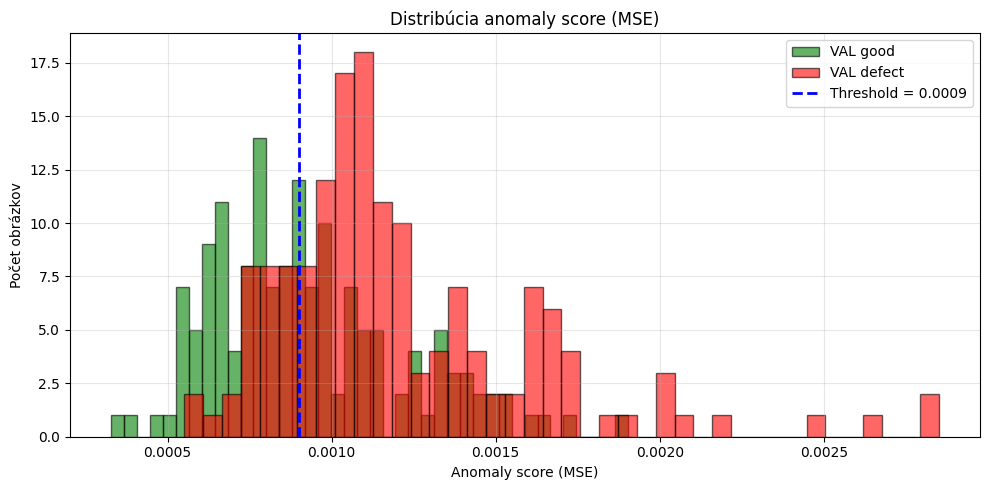

In [40]:
val_normal_scores = get_anomaly_scores(val_good_loader, model, device)
val_defect_scores = get_anomaly_scores(val_def_loader, model, device)

y_val_true = np.concatenate([
    np.zeros(len(val_normal_scores), dtype=int),
    np.ones(len(val_defect_scores), dtype=int)
])
y_val_scores = np.concatenate([val_normal_scores, val_defect_scores])

thresholds = np.linspace(y_val_scores.min(), y_val_scores.max(), 500)
best_thresh = None
best_f1 = -1

for thr in thresholds:
    y_val_pred = (y_val_scores > thr).astype(int)
    f1 = f1_score(y_val_true, y_val_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thr

RECON_THRESH = best_thresh

print("=" * 60)
print("THRESHOLD Z VALIDÁCIE (MSE Loss)")
print("=" * 60)
print(f"Best threshold: {RECON_THRESH:.6f}")
print(f"Best validation F1: {best_f1:.6f}")

plt.figure(figsize=(10, 5))
plt.hist(val_normal_scores, bins=40, alpha=0.6, color='green', label='VAL good', edgecolor='black')
plt.hist(val_defect_scores, bins=40, alpha=0.6, color='red', label='VAL defect', edgecolor='black')
plt.axvline(RECON_THRESH, color='blue', linestyle='--', linewidth=2, label=f'Threshold = {RECON_THRESH:.4f}')
plt.title('Distribúcia anomaly score (MSE)')
plt.xlabel('Anomaly score (MSE)')
plt.ylabel('Počet obrázkov')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANALÝZA NAJHORŠÍCH 'DOBRÝCH' OBRAZOV (Odlesky/Problémy)


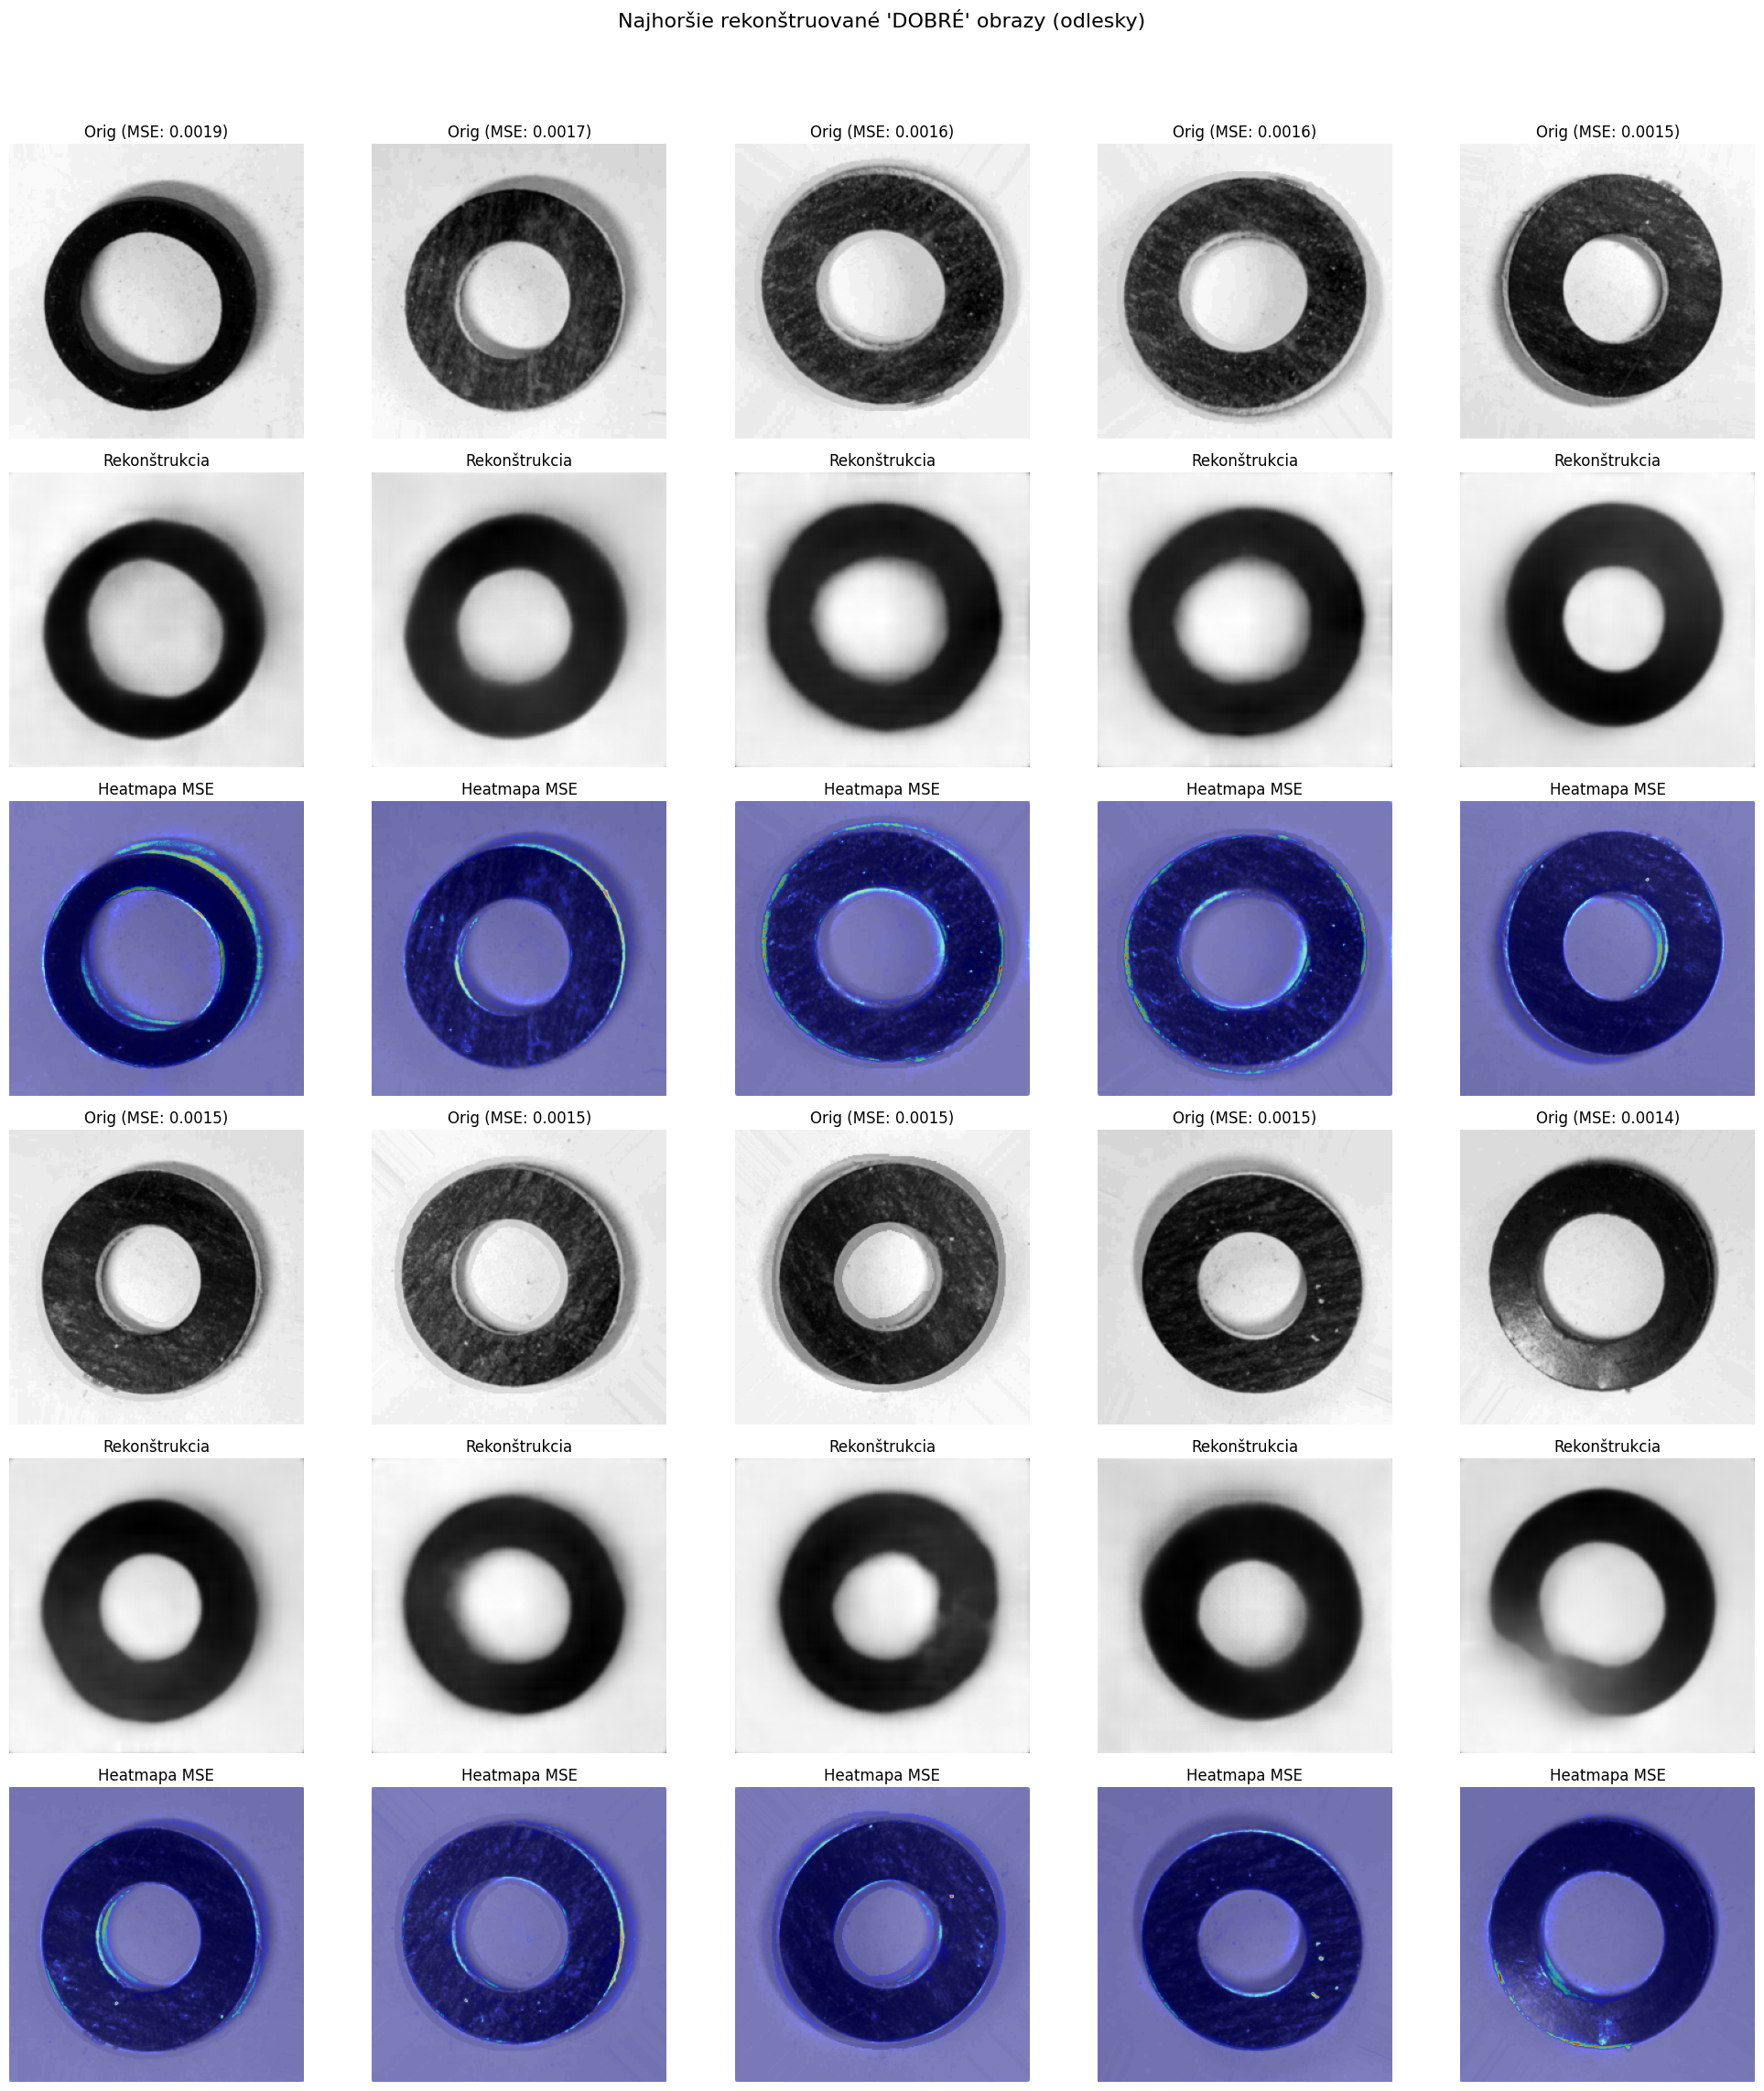

In [41]:
def show_worst_good_images(model, loader, device, num_images=10, num_cols=5):
    print("=" * 60)
    print("ANALÝZA NAJHORŠÍCH 'DOBRÝCH' OBRAZOV (Odlesky/Problémy)")
    print("=" * 60)
    model.eval()
    
    image_data = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructions = model(images)
            anomaly_score, error_map = mse_anomaly_score(reconstructions, images)
            
            for i in range(images.size(0)):
                image_data.append({
                    'orig': images[i].cpu(),
                    'recon': reconstructions[i].cpu(),
                    'error_map': error_map[i].cpu(),
                    'score': anomaly_score[i].item()
                })
                
    image_data.sort(key=lambda x: x['score'], reverse=True)
    top_worst = image_data[:num_images]
    
    num_rows = math.ceil(len(top_worst) / num_cols)
    fig, axes = plt.subplots(num_rows * 3, num_cols, figsize=(4 * num_cols, 4 * num_rows * 3))
    fig.suptitle("Najhoršie rekonštruované 'DOBRÉ' obrazy (odlesky)", fontsize=16)
    
    for i, data in enumerate(top_worst):
        block, col = i // num_cols, i % num_cols
        orig_row, rec_row, heat_row = block * 3, block * 3 + 1, block * 3 + 2
        
        img_np = data['orig'].squeeze().numpy()
        rec_np = data['recon'].squeeze().numpy()
        err_np = data['error_map'].squeeze().numpy()
        
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"Orig (MSE: {data['score']:.4f})")
        axes[orig_row, col].axis('off')
        
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        
        axes[heat_row, col].imshow(img_np, cmap='gray')
        normalized_err_np = err_np / np.max(err_np) if np.max(err_np) > 0 else err_np
        axes[heat_row, col].imshow(normalized_err_np, cmap='jet', alpha=0.5) 
        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')
        
    for j in range(len(top_worst), num_rows * num_cols):
        block, col = j // num_cols, j % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_worst_good_images(model, val_good_loader, device, num_images=10)

POROVNANIE VÝSLEDKOV PRE RÔZNE HODNOTY THRESHOLD (Test Set)
|  Threshold   | Precision  |  Recall (Defekty)  |  F1-Score  |  Falošné Detekcie (FP)  |
|--------------|------------|--------------------|------------|-------------------------|
|   0.00090    |   0.6637   |       0.8362       |   0.7400   |           75            |
|   0.00103    |   0.7235   |       0.6949       |   0.7089   |           47            |
|   0.00180    |   0.8889   |       0.1356       |   0.2353   |            3            |


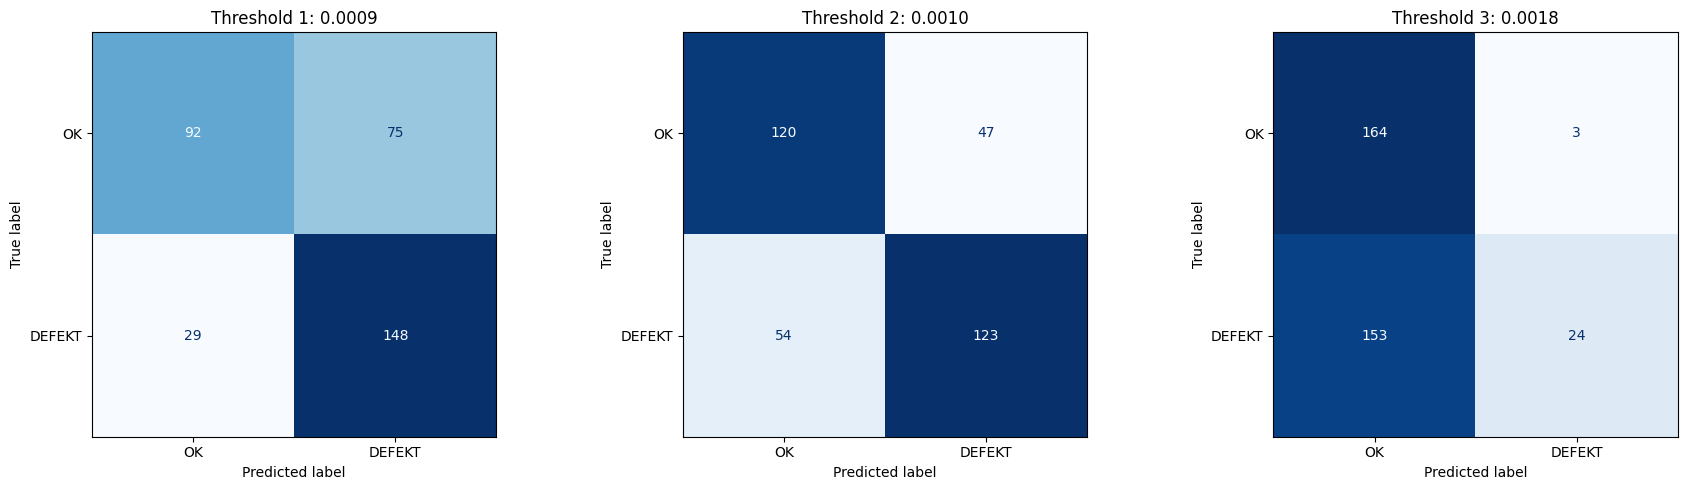

In [42]:
test_normal_scores = get_anomaly_scores(test_good_loader, model, device)
test_defect_scores = get_anomaly_scores(test_def_loader, model, device)

y_test_true = np.concatenate([
    np.zeros(len(test_normal_scores), dtype=int),
    np.ones(len(test_defect_scores), dtype=int)
])
y_test_scores = np.concatenate([test_normal_scores, test_defect_scores])

thresh_1 = RECON_THRESH
thresh_2 = RECON_THRESH * 1.15 
thresh_3 = RECON_THRESH * 2.0

print("=" * 60)
print("POROVNANIE VÝSLEDKOV PRE RÔZNE HODNOTY THRESHOLD (Test Set)")
print("=" * 60)
table_header = f"| {'Threshold':^12} | {'Precision':^10} | {'Recall (Defekty)':^18} | {'F1-Score':^10} | {'Falošné Detekcie (FP)':^23} |"
print(table_header)
print("|" + "-"*14 + "|" + "-"*12 + "|" + "-"*20 + "|" + "-"*12 + "|" + "-"*25 + "|")

for t in [thresh_1, thresh_2, thresh_3]:
    y_pred_t = (y_test_scores > t).astype(int)
    cm_t = confusion_matrix(y_test_true, y_pred_t)
    fp_count = cm_t[0, 1] 
    
    prec = precision_score(y_test_true, y_pred_t, zero_division=0)
    rec = recall_score(y_test_true, y_pred_t, zero_division=0)
    f1_s = f1_score(y_test_true, y_pred_t, zero_division=0)
    
    row = f"| {t:^12.5f} | {prec:^10.4f} | {rec:^18.4f} | {f1_s:^10.4f} | {fp_count:^23} |"
    print(row)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
thresholds_list = [thresh_1, thresh_2, thresh_3]
titles = [f'Threshold 1: {thresh_1:.4f}', f'Threshold 2: {thresh_2:.4f}', f'Threshold 3: {thresh_3:.4f}']

for i, t in enumerate(thresholds_list):
    y_pred_t = (y_test_scores > t).astype(int)
    cm_t = confusion_matrix(y_test_true, y_pred_t)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=['OK', 'DEFEKT'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d', colorbar=False)
    axes[i].set_title(titles[i])

plt.tight_layout()
plt.show()

In [ ]:
def show_false_positives(model, test_good_loader, device, RECON_THRESH, num_images=15, num_cols=5):
    print("\n" + "=" * 60)
    print("ANALÝZA FALSE POSITIVES (Originál = OK, Predikovaný = DEFEKT)")
    print("=" * 60)

    model.eval()
    fp_images_data = []

    with torch.no_grad():
        for images_batch, _ in test_good_loader:
            images_batch = images_batch.to(device)

            reconstructions_batch = model(images_batch)

            anomaly_score_batch, error_map_batch = mse_anomaly_score(
                reconstructions_batch,
                images_batch
            )

            fp_indices_in_batch = (anomaly_score_batch > RECON_THRESH).nonzero(as_tuple=True)[0]

            for fp_idx_in_batch in fp_indices_in_batch:
                if len(fp_images_data) < num_images:
                    original_img = images_batch[fp_idx_in_batch].cpu()
                    reconstructed_img = reconstructions_batch[fp_idx_in_batch].cpu()
                    error_map_img = error_map_batch[fp_idx_in_batch].cpu()
                    score = anomaly_score_batch[fp_idx_in_batch].item()

                    fp_images_data.append(
                        (original_img, reconstructed_img, error_map_img, score)
                    )
                else:
                    break

            if len(fp_images_data) >= num_images:
                break

    if not fp_images_data:
        print("Neboli nájdené žiadne False Positive obrázky s aktuálnym MSE prahom.")
        return

    num_images_to_show = len(fp_images_data)
    num_rows = math.ceil(num_images_to_show / num_cols)

    fig, axes = plt.subplots(
        num_rows * 3,
        num_cols,
        figsize=(4 * num_cols, 4 * num_rows * 3 + num_rows * 2)
    )

    fig.suptitle(
        f"Príklady False Positives - čisté MSE, Threshold: {RECON_THRESH:.6f}",
        fontsize=16
    )

    for i in range(num_images_to_show):
        orig_img, rec_img, err_map_img, score = fp_images_data[i]

        block = i // num_cols
        col = i % num_cols

        orig_row = block * 3
        rec_row = block * 3 + 1
        heat_row = block * 3 + 2

        img_np = orig_img.squeeze().numpy()
        rec_np = rec_img.squeeze().numpy()
        err_np = err_map_img.squeeze().numpy()

        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"Orig. MSE: {score:.6f}")
        axes[orig_row, col].axis('off')

        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')

        axes[heat_row, col].imshow(img_np, cmap='gray')

        normalized_err_np = err_np / np.max(err_np) if np.max(err_np) > 0 else err_np
        axes[heat_row, col].imshow(normalized_err_np, cmap='jet', alpha=0.5)

        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')

    for j in range(num_images_to_show, num_rows * num_cols):
        block = j // num_cols
        col = j % num_cols

        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

show_false_positives(
    model,
    test_good_loader,
    device,
    RECON_THRESH,
    num_images=15
)

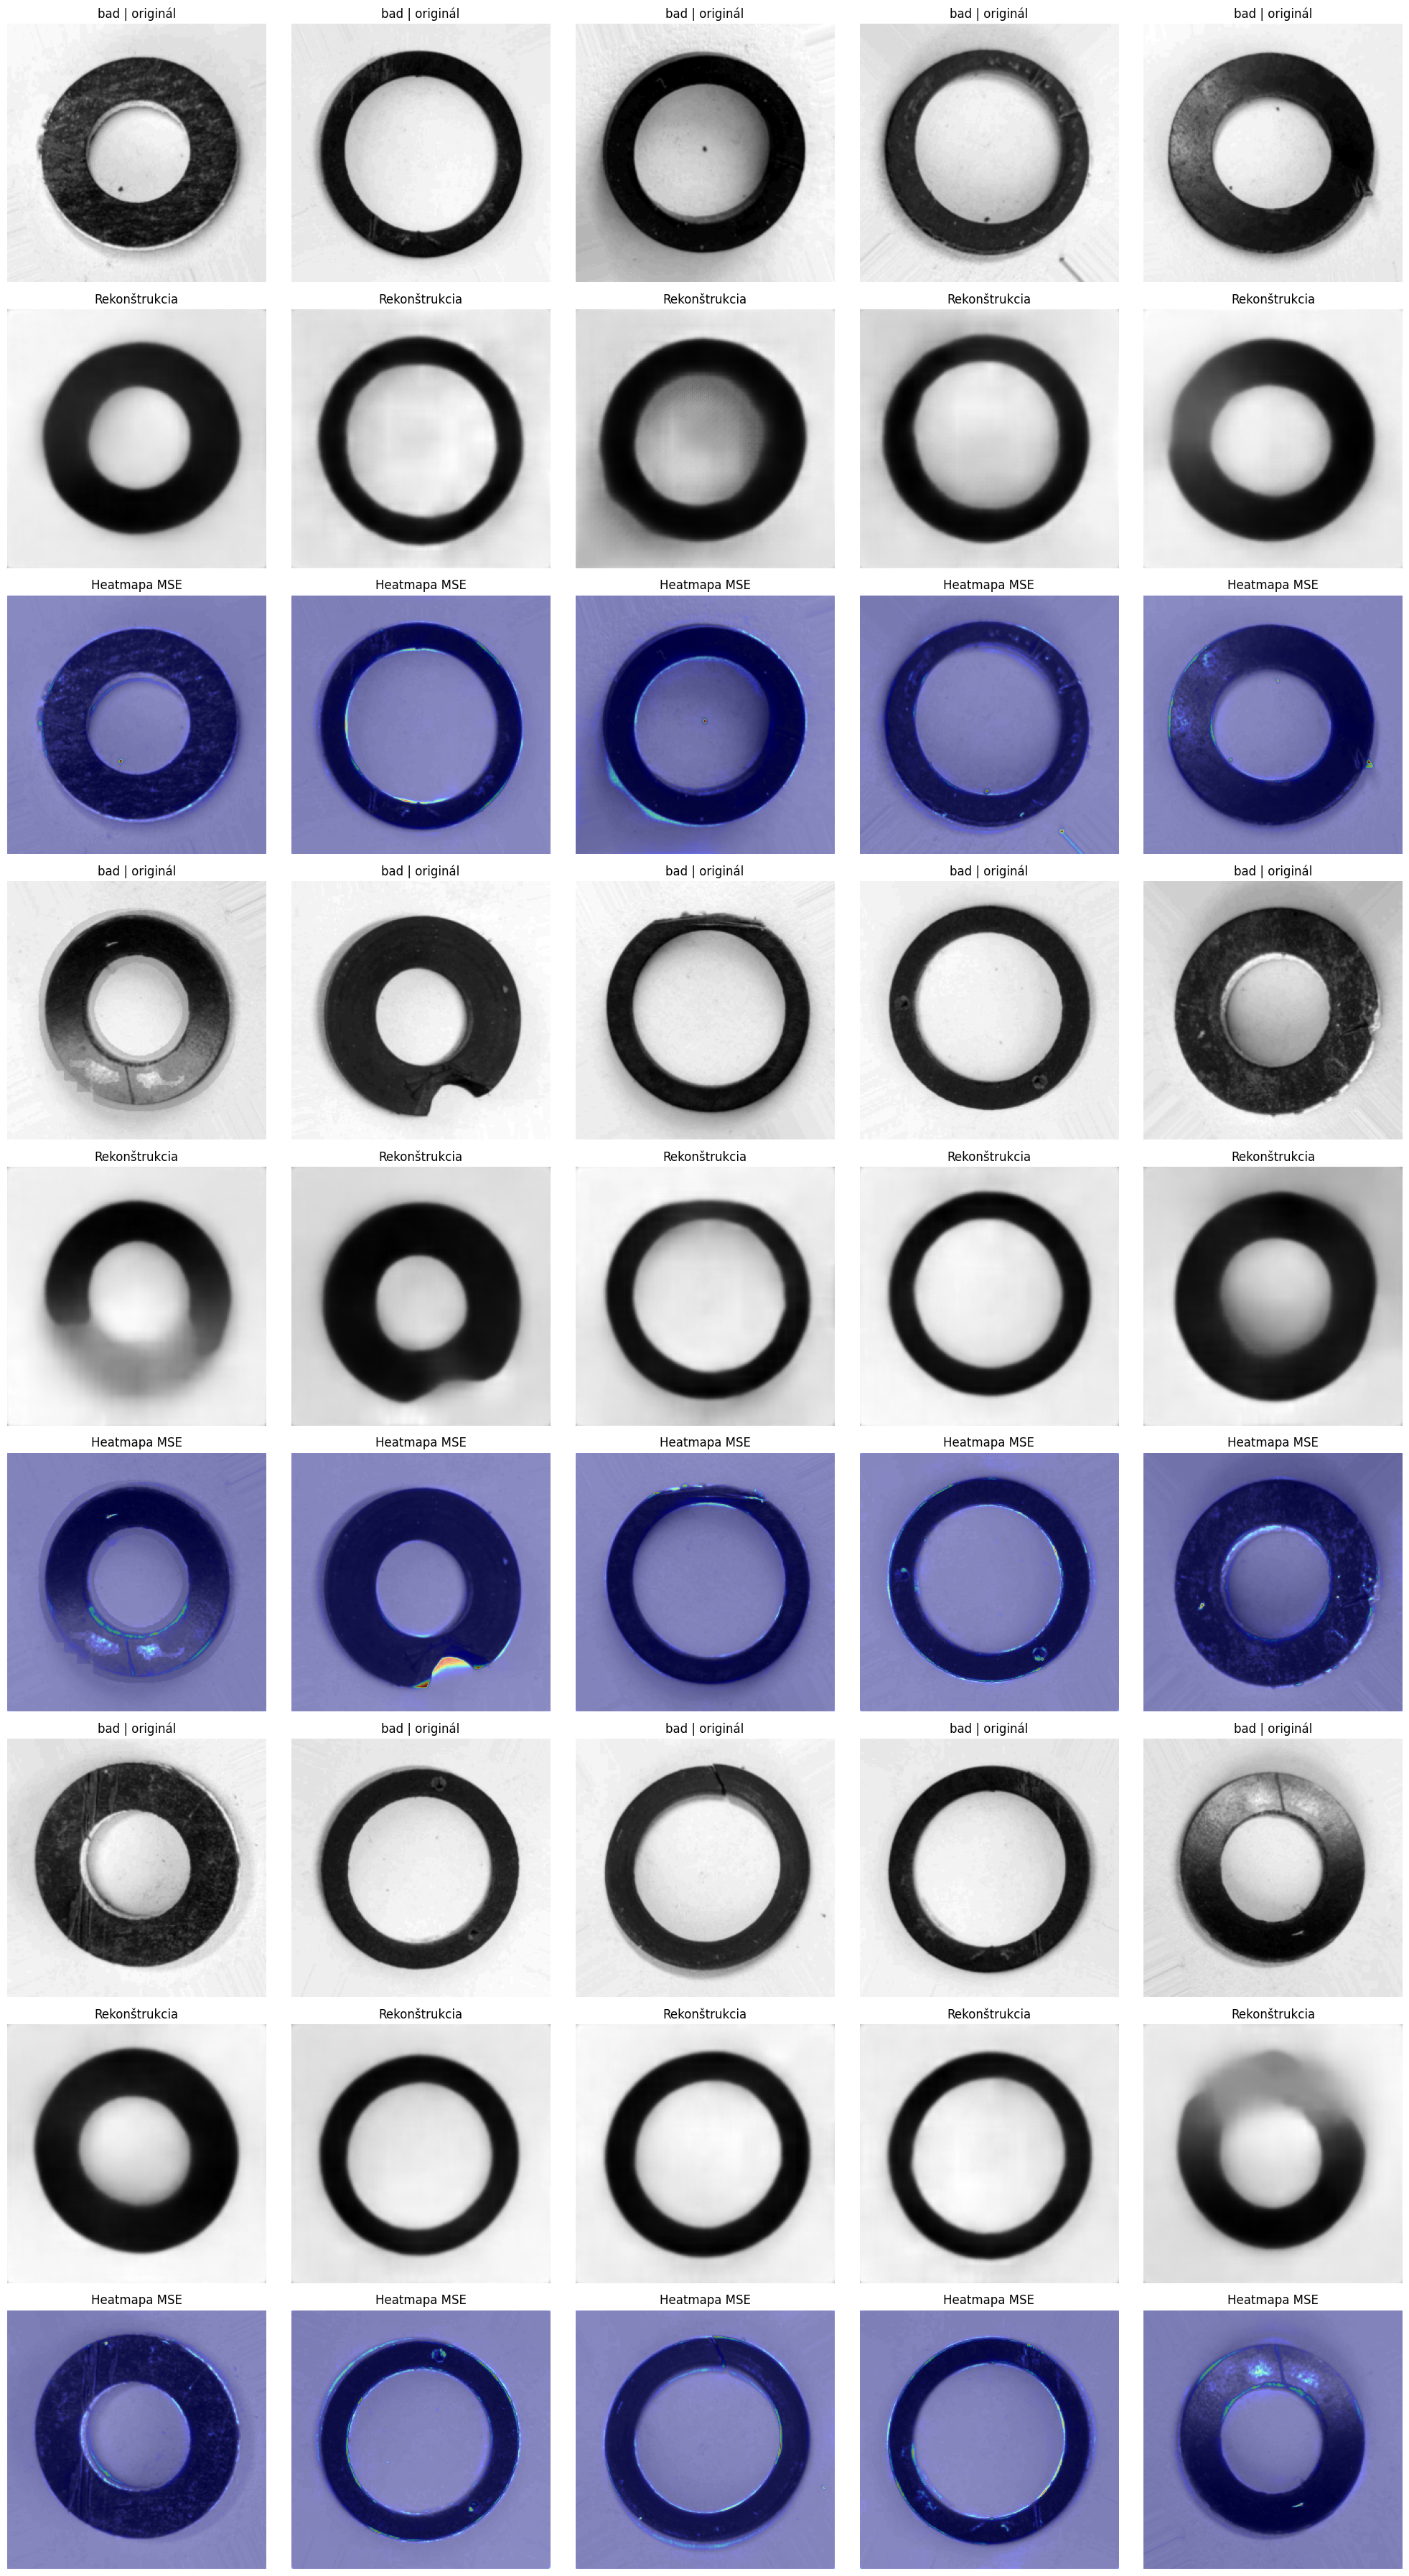

In [44]:
def show_anomaly_heatmaps(model, dataset, subset_loader, device, num_images=15, num_cols=5):
    model.eval()
    subset_indices = subset_loader.dataset.indices
    num_images = min(num_images, len(subset_indices))
    random_indices = random.sample(subset_indices, num_images)
    random_images = []
    random_labels = []
    
    for idx in random_indices:
        img, label = dataset[idx]
        random_images.append(img)
        random_labels.append(dataset.classes[label])
        
    images = torch.stack(random_images).to(device)
    with torch.no_grad():
        reconstructions = model(images)
        _, error_maps = mse_anomaly_score(reconstructions, images)
        
    num_blocks = math.ceil(num_images / num_cols)
    fig, axes = plt.subplots(num_blocks * 3, num_cols, figsize=(4 * num_cols, 4 * num_blocks * 3))
    
    for i in range(num_images):
        block = i // num_cols
        col = i % num_cols
        orig_row = block * 3
        rec_row = block * 3 + 1
        heat_row = block * 3 + 2
        
        img_np = images[i].cpu().squeeze().numpy()
        rec_np = reconstructions[i].cpu().squeeze().numpy()
        err_np = error_maps[i].cpu().squeeze().numpy()
        
        axes[orig_row, col].imshow(img_np, cmap='gray')
        axes[orig_row, col].set_title(f"{random_labels[i]} | originál")
        axes[orig_row, col].axis('off')
        
        axes[rec_row, col].imshow(rec_np, cmap='gray')
        axes[rec_row, col].set_title("Rekonštrukcia")
        axes[rec_row, col].axis('off')
        
        axes[heat_row, col].imshow(img_np, cmap='gray')
        axes[heat_row, col].imshow(err_np, cmap='jet', alpha=0.45)
        axes[heat_row, col].set_title("Heatmapa MSE")
        axes[heat_row, col].axis('off')
        
    total_slots = num_blocks * num_cols
    for i in range(num_images, total_slots):
        block = i // num_cols
        col = i % num_cols
        axes[block * 3, col].axis('off')
        axes[block * 3 + 1, col].axis('off')
        axes[block * 3 + 2, col].axis('off')
        
    plt.tight_layout()
    plt.show()

show_anomaly_heatmaps(model, dataset_test, test_def_loader, device, num_images=15)